<a href="https://colab.research.google.com/github/Nehabisht098/Applied-AIML-LAB-EXPERIMENTS/blob/main/Experiment_4_EDA__AIML_2026_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ------------------------------------------
# STEP 1: Import required libraries
# ------------------------------------------

import pandas as pd          # data handling
import numpy as np           # numerical operations
import matplotlib.pyplot as plt   # visualization
import seaborn as sns        # advanced visualization




# ------------------------------------------
# STEP 2: Load the dataset
# ------------------------------------------

# Read CSV file
df = pd.read_csv("/Titanic-Dataset (1).csv")

# View first 5 rows
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# ------------------------------------------
# STEP 3: Understand the dataset structure
# ------------------------------------------

# Shape of dataset
df.shape

# Column names
df.columns

# Data types & non-null values
df.info()

# Summary statistics
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# ------------------------------------------
# STEP 4: Check missing values
# ------------------------------------------

df.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# ------------------------------------------
# STEP 5: Handle missing values
# ------------------------------------------

# Fill Age with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill Embarked with mode
#"Give me the first most frequent value."
#.mode()
#Returns the most frequent value(s).
#It returns a Series, not a single value.
#[0]Takes the first mode value (in case there are multiple modes).
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin (too many missing values)
#In pandas:axis=0 → rows axis=1 → columns
df.drop('Cabin', axis=1, inplace=True)

# Recheck missing values
df.isnull().sum()


/tmp/ipykernel_3175/4158976340.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_3175/4158976340.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

KeyError: "['Cabin'] not found in axis"

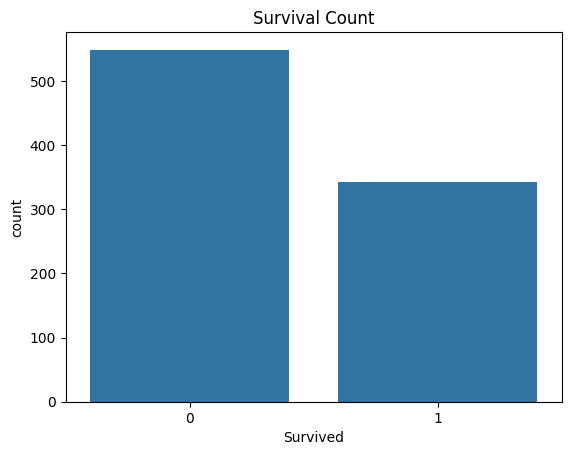

In [ ]:
# ------------------------------------------
# STEP 6: Univariate Analysis
# (analysis of single variable)
# ------------------------------------------
# Survival count
#Survived column is a binary variable.Survived column is a binary variable.
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

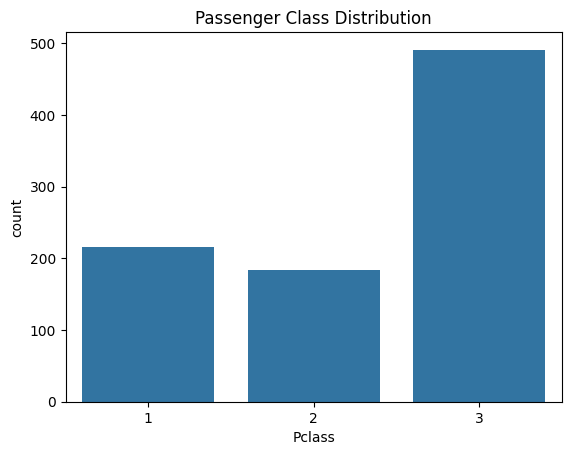

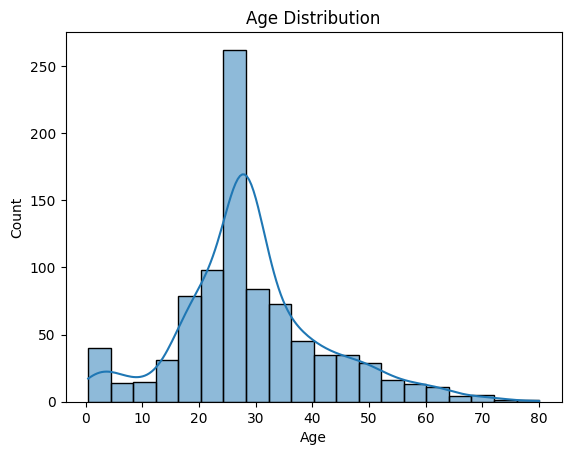

In [ ]:




# Passenger class distribution
# countplot counts
# how many passengers are in each class.
# 1 → Number of First Class passengers
# 2 → Number of Second Class passengers
# 3 → Number of Third Class passengers
sns.countplot(x='Pclass', data=df)
plt.title("Passenger Class Distribution")
plt.show()

# Age distribution
# bins=20 means:
# Divide the Age range into 20 equal intervals.
# More bins → more detailed
# Fewer bins → smoother but less detailed
#KDE = Kernel Density Estimation

#It draws a smooth curve over the histogram.
#Histogram → blocky bars
#KDE → smooth probability curve
#It helps you see the overall pattern more clearly.
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()


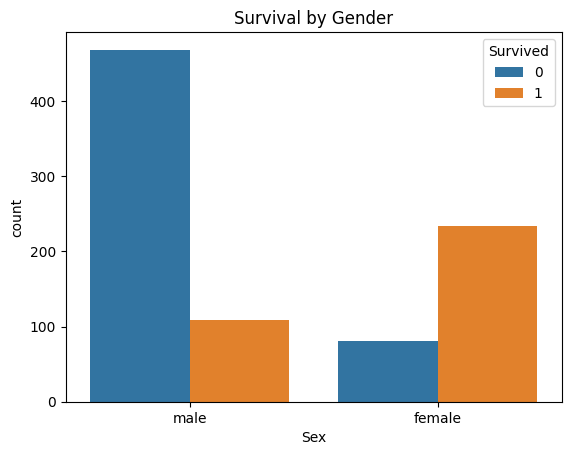

In [ ]:
# ------------------------------------------
# STEP 7: Bivariate Analysis
# (relation between two variables)
# ------------------------------------------

# Survival vs Gender
# In seaborn hue adds a second variable using color separation
# conclucion : Most males → did NOT survive
# Most females → survived
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

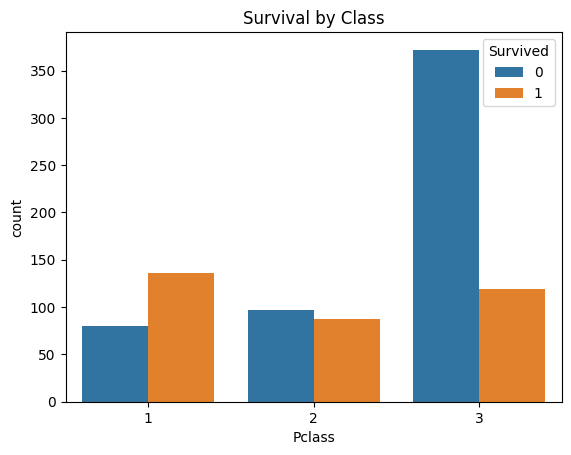

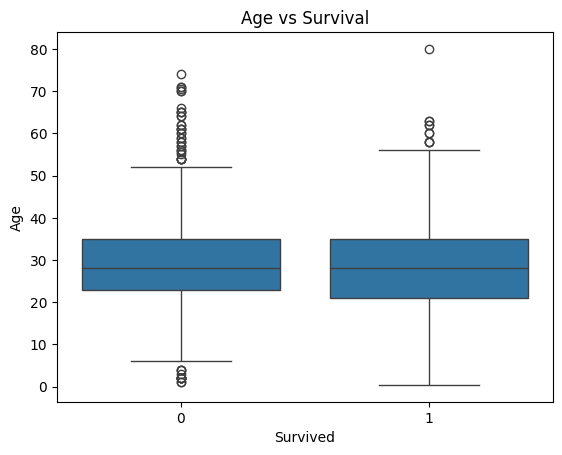

In [ ]:


# Survival vs Passenger class
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Class")
plt.show()

# Age vs Survival
sns.boxplot(x='Survived', y='Age', data=df)
plt.title("Age vs Survival")
plt.show()


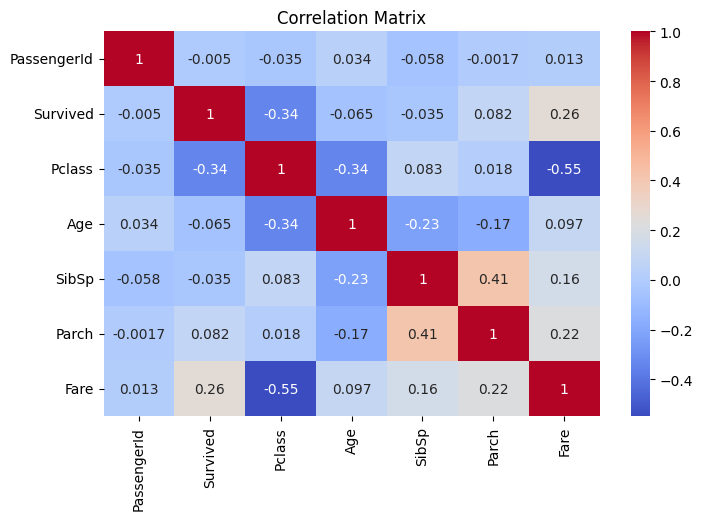

In [ ]:
# ------------------------------------------
# STEP 8: Multivariate Analysis
# ------------------------------------------

# Correlation matrix
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


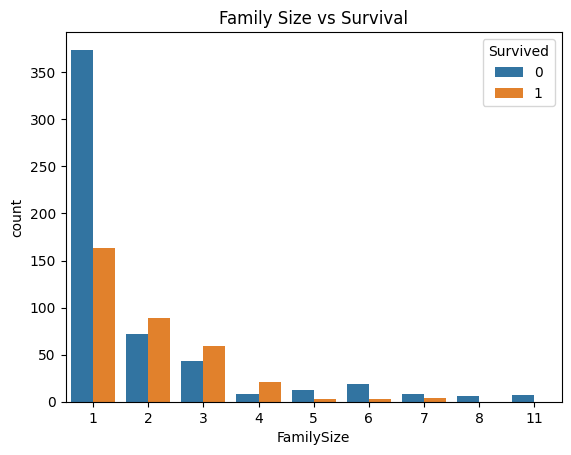

In [ ]:
# ------------------------------------------
# STEP 9: Feature Engineering
# ------------------------------------------

# Create Family Size feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Visualize family size vs survival
sns.countplot(x='FamilySize', hue='Survived', data=df)
plt.title("Family Size vs Survival")
plt.show()


In [ ]:
# ------------------------------------------
# STEP 10: Insights from EDA
# ------------------------------------------

# Average survival by gender
#df.groupby('Sex')['Survived'].mean()

# Average survival by class
#df.groupby('Pclass')['Survived'].mean()

# Average age of survivors vs non-survivors
df.groupby('Survived')['Age'].mean()


,Age
Survived,
0,30.028233
1,28.291433


In [ ]:
df.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [ ]:
df.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908
